# 第 2 题：卷积和池化层

## 2.1 理论计算题

**已知参数：**
* 输入图像尺寸：$C_{in}=3$, $H_{in}=32$, $W_{in}=32$
* 卷积核数量：$C_{out}=16$
* 卷积核大小：$K_h=5$, $K_w=5$ （注：对于输入，完整的卷积核大小为 $3 \times 5 \times 5$）
* 填充 (Padding)：$P=2$
* 步幅 (Stride)：$S=2$

**1. 计算卷积层输出的特征图（Feature Map）尺寸：**

输出特征图的高和宽计算公式为：
$$H_{out} = \lfloor \frac{H_{in} + 2P - K_h}{S} \rfloor + 1$$
$$W_{out} = \lfloor \frac{W_{in} + 2P - K_w}{S} \rfloor + 1$$

代入数值：
$$H_{out} = \lfloor \frac{32 + 2 \times 2 - 5}{2} \rfloor + 1 = \lfloor \frac{31}{2} \rfloor + 1 = 15 + 1 = 16$$
$$W_{out} = \lfloor \frac{32 + 2 \times 2 - 5}{2} \rfloor + 1 = 16$$

由于有 16 个卷积核，输出通道数 $C_{out} = 16$。
**结论：** 输出的特征图尺寸为 **$16 \times 16 \times 16$**（通道数 × 高 × 宽）。

---

**2. 计算单个输出像素的点乘（乘法）操作次数：**

输出特征图中的一个像素值，是由一个完整的卷积核与输入图像上对应区域的感受野进行逐元素点乘求和得到的。
每次点乘操作的次数等于一个完整卷积核的参数体积：
$$ \text{点乘次数} = C_{in} \times K_h \times K_w = 3 \times 5 \times 5 = 75 $$

**结论：** 单个输出通道的一个像素值需要进行 **75** 次点乘操作。



## 2.2 编程题
不使用深度学习框架的底层 Pooling API（如 `torch.nn.MaxPool2d`），仅使用 Python 和 PyTorch 基础张量操作，手动实现一个支持步幅（stride）和填充（padding）的二维最大池化（Max Pooling）前向传播函数。


In [1]:
import torch

def max_pool2d_manual(X, pool_size, stride=None, padding=0):
    """
    手动实现二维最大池化前向传播 (支持 padding 和 stride)
    
    参数:
    X: 输入张量，形状为 (batch_size, channels, height, width)
    pool_size: 池化窗口大小，int 或 tuple (ph, pw)
    stride: 步幅，int 或 tuple (sh, sw)，默认与 pool_size 相同
    padding: 填充，int 或 tuple (pad_h, pad_w)
    """
    # 参数预处理
    if isinstance(pool_size, int):
        pool_size = (pool_size, pool_size)
    if stride is None:
        stride = pool_size
    elif isinstance(stride, int):
        stride = (stride, stride)
    if isinstance(padding, int):
        padding = (padding, padding)
        
    ph, pw = pool_size
    sh, sw = stride
    pad_h, pad_w = padding
    
    batch_size, channels, in_h, in_w = X.shape
    
    # 计算输出尺寸
    out_h = int((in_h + 2 * pad_h - ph) / sh) + 1
    out_w = int((in_w + 2 * pad_w - pw) / sw) + 1
    
    # 对输入进行负无穷填充
    # 注意：因为是最大池化，填充区域必须是极小值(-inf)，这样才不会影响有效区域求最大值
    X_padded = torch.full(
        (batch_size, channels, in_h + 2 * pad_h, in_w + 2 * pad_w), 
        float('-inf'), 
        dtype=X.dtype, 
        device=X.device
    )
    # 将原始数据填入中心区域
    X_padded[:, :, pad_h:pad_h+in_h, pad_w:pad_w+in_w] = X
    
    # 初始化输出张量
    out = torch.zeros((batch_size, channels, out_h, out_w), dtype=X.dtype, device=X.device)
    
    # 执行滑动窗口的最大池化操作
    for b in range(batch_size):
        for c in range(channels):
            for i in range(out_h):
                for j in range(out_w):
                    # 计算池化窗口在输入上的起始和结束索引
                    h_start = i * sh
                    h_end = h_start + ph
                    w_start = j * sw
                    w_end = w_start + pw
                    
                    # 提取窗口并求取该窗口内的最大值
                    window = X_padded[b, c, h_start:h_end, w_start:w_end]
                    out[b, c, i, j] = torch.max(window)
                    
    return out

# ==========================================
# 测试与验证
# ==========================================
print("=== 测试手动实现的 Max Pooling ===")
torch.manual_seed(42)

# 创建一个随机输入 (batch_size=1, channels=1, height=4, width=4)
X_test = torch.randn(1, 1, 4, 4)
print("\n输入张量 X:")
print(X_test)

# 参数设置
p_size = 2
p_stride = 2
p_padding = 1

# 1. 手动计算结果
out_manual = max_pool2d_manual(X_test, pool_size=p_size, stride=p_stride, padding=p_padding)
print("\n手动实现输出 (Manual):")
print(out_manual)

# 2. PyTorch 官方 API 结果 (用于对比验证)
pool_layer = torch.nn.MaxPool2d(kernel_size=p_size, stride=p_stride, padding=p_padding)
out_official = pool_layer(X_test)
print("\nPyTorch 官方 API 输出 (Official):")
print(out_official)

# 验证两者是否完全一致
is_same = torch.allclose(out_manual, out_official)
print(f"\n=> 验证结果: {'一致 (Success)!' if is_same else '不一致 (Failed)'}")


=== 测试手动实现的 Max Pooling ===

输入张量 X:
tensor([[[[ 1.9269,  1.4873,  0.9007, -2.1055],
          [ 0.6784, -1.2345, -0.0431, -1.6047],
          [-0.7521,  1.6487, -0.3925, -1.4036],
          [-0.7279, -0.5594, -0.7688,  0.7624]]]])

手动实现输出 (Manual):
tensor([[[[ 1.9269,  1.4873, -2.1055],
          [ 0.6784,  1.6487, -1.4036],
          [-0.7279, -0.5594,  0.7624]]]])

PyTorch 官方 API 输出 (Official):
tensor([[[[ 1.9269,  1.4873, -2.1055],
          [ 0.6784,  1.6487, -1.4036],
          [-0.7279, -0.5594,  0.7624]]]])

=> 验证结果: 一致 (Success)!


# 第 3 题：LeNet, AlexNet, VGG 和 NiN

## 3.1 理论计算题

**已知条件：** 输入特征图通道数为 $C$，输出特征图通道数也为 $C$。且不计算偏置项。

**1. 一个 $5 \times 5$ 卷积层的参数量：**
卷积层的参数量计算公式为：$C_{in} \times K_h \times K_w \times C_{out}$。
代入已知条件：
$$ \text{参数量} = C \times 5 \times 5 \times C = 25C^2 $$

**2. 两个串联的 $3 \times 3$ 卷积层的总参数量：**
第一层参数量：$C \times 3 \times 3 \times C = 9C^2$
第二层参数量：$C \times 3 \times 3 \times C = 9C^2$
总参数量：
$$ \text{总参数量} = 9C^2 + 9C^2 = 18C^2 $$

**结论：** 
一个 $5 \times 5$ 卷积层的参数量为 $25C^2$，而两个串联的 $3 \times 3$ 卷积层（这两层串联拥有与单层 $5 \times 5$ 相同的感受野）总参数量仅为 $18C^2$。
在 VGG 中频繁使用多个 $3 \times 3$ 小卷积核级联，不仅可以显著减少网络参数量（$18C^2 < 25C^2$），降低计算开销，还能因为层数增加、多加了一层非线性激活函数（ReLU），从而增强网络的非线性表达能力。



## 3.2 编程题
NiN 网络的核心创新是引入了“1x1 卷积”组成的 NiN 块来代替传统的全连接层，以减少参数量。请使用 PyTorch (`torch.nn.Sequential`) 定义一个标准的 NiN 块 (NiN Block)。


In [3]:
import torch
from torch import nn

def nin_block(in_channels, out_channels, kernel_size, stride, padding):
    """
    构建一个标准的 NiN 块 (NiN Block)
    
    参数:
    in_channels: 输入通道数
    out_channels: 输出通道数
    kernel_size: 空间卷积的窗口大小
    stride: 空间卷积的步幅
    padding: 空间卷积的填充
    """
    block = nn.Sequential(
        # 1. 普通空间卷积层 + ReLU
        nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
        nn.ReLU(),
        
        # 2. 第一个 1x1 卷积层 + ReLU
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU(),
        
        # 3. 第二个 1x1 卷积层 + ReLU
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU()
    )
    return block

# ==========================================
# 测试与验证 NiN 块
# ==========================================
print("=== 测试 NiN 块结构 ===")

# 实例化一个 NiN 块
# 假设输入通道数为 3 (如RGB图像)，输出通道数为 96，使用 5x5 的卷积核，padding 为 2
block = nin_block(in_channels=3, out_channels=96, kernel_size=5, stride=1, padding=2)

# 打印网络结构以供检查
print(block)

# 测试前向传播，验证输出形状
# 创建一个随机输入张量 (batch_size=1, channels=3, height=32, width=32)
X_test = torch.randn(1, 3, 32, 32)
out = block(X_test)

print(f"\n输入形状: {X_test.shape}")
print(f"输出形状: {out.shape}")


=== 测试 NiN 块结构 ===
Sequential(
  (0): Conv2d(3, 96, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (1): ReLU()
  (2): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1))
  (3): ReLU()
  (4): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1))
  (5): ReLU()
)

输入形状: torch.Size([1, 3, 32, 32])
输出形状: torch.Size([1, 96, 32, 32])


# 第 4 题：Inception, 批量归一化和残差网络

## 4.1 理论计算题

**已知条件：**
* 样本特征值：$x_1 = 2, x_2 = 4, x_3 = 6, x_4 = 8$
* 小批量大小：$m = 4$
* 缩放参数：$\gamma = 2$
* 平移参数：$\beta = 1$
* 常数：$\epsilon = 0$

**计算步骤：**

**1. 计算小批量均值 ($\mu_{\mathcal{B}}$)：**
$$ \mu_{\mathcal{B}} = \frac{1}{m} \sum_{i=1}^{m} x_i = \frac{2 + 4 + 6 + 8}{4} = \frac{20}{4} = 5 $$

**2. 计算小批量方差 ($\sigma^2_{\mathcal{B}}$)：**
$$ \sigma^2_{\mathcal{B}} = \frac{1}{m} \sum_{i=1}^{m} (x_i - \mu_{\mathcal{B}})^2 $$
$$ \sigma^2_{\mathcal{B}} = \frac{1}{4} \left[ (2 - 5)^2 + (4 - 5)^2 + (6 - 5)^2 + (8 - 5)^2 \right] $$
$$ \sigma^2_{\mathcal{B}} = \frac{1}{4} \left[ (-3)^2 + (-1)^2 + 1^2 + 3^2 \right] = \frac{9 + 1 + 1 + 9}{4} = \frac{20}{4} = 5 $$

**3. 进行标准化 ($\hat{x}_i$)：**
$$ \hat{x}_i = \frac{x_i - \mu_{\mathcal{B}}}{\sqrt{\sigma^2_{\mathcal{B}} + \epsilon}} = \frac{x_i - 5}{\sqrt{5}} $$
*   $\hat{x}_1 = \frac{2 - 5}{\sqrt{5}} = -\frac{3}{\sqrt{5}}$
*   $\hat{x}_2 = \frac{4 - 5}{\sqrt{5}} = -\frac{1}{\sqrt{5}}$
*   $\hat{x}_3 = \frac{6 - 5}{\sqrt{5}} = \frac{1}{\sqrt{5}}$
*   $\hat{x}_4 = \frac{8 - 5}{\sqrt{5}} = \frac{3}{\sqrt{5}}$

**4. 缩放与平移 (计算最终输出 $y_i$)：**
$$ y_i = \gamma \hat{x}_i + \beta = 2 \hat{x}_i + 1 $$
*   $y_1 = 2 \times \left(-\frac{3}{\sqrt{5}}\right) + 1 = 1 - \frac{6}{\sqrt{5}} \approx 1 - 2.683 = -1.683$
*   $y_2 = 2 \times \left(-\frac{1}{\sqrt{5}}\right) + 1 = 1 - \frac{2}{\sqrt{5}} \approx 1 - 0.894 = 0.106$
*   $y_3 = 2 \times \left(\frac{1}{\sqrt{5}}\right) + 1 = 1 + \frac{2}{\sqrt{5}} \approx 1 + 0.894 = 1.894$
*   $y_4 = 2 \times \left(\frac{3}{\sqrt{5}}\right) + 1 = 1 + \frac{6}{\sqrt{5}} \approx 1 + 2.683 = 3.683$

**结论：** 转化后的最终输出值（精确值）为：
*   **$y_1 = 1 - \frac{6}{\sqrt{5}}$**
*   **$y_2 = 1 - \frac{2}{\sqrt{5}}$**
*   **$y_3 = 1 + \frac{2}{\sqrt{5}}$**
*   **$y_4 = 1 + \frac{6}{\sqrt{5}}$**



## 4.2 编程题
残差网络（ResNet）通过引入跨层连接（残差连接）解决了深层网络的梯度消失问题。请用 PyTorch 自定义一个残差块类 `Residual`。


In [4]:
import torch
from torch import nn
from torch.nn import functional as F

class Residual(nn.Module):
    def __init__(self, input_channels, num_channels, use_1x1conv=False, strides=1):
        """
        构建一个残差块 (Residual Block)
        
        参数:
        input_channels: 输入通道数
        num_channels: 卷积层的输出通道数
        use_1x1conv: 是否使用 1x1 卷积层来调整输入维度 (用于通道数改变或步幅减半时)
        strides: 第一个卷积层的步幅
        """
        super().__init__()
        
        # 两个串联的 3x3 卷积层
        # 第一层可能包含 strides 以减半空间维度
        self.conv1 = nn.Conv2d(input_channels, num_channels, kernel_size=3, padding=1, stride=strides)
        self.conv2 = nn.Conv2d(num_channels, num_channels, kernel_size=3, padding=1)
        
        # 对应的批量归一化层
        self.bn1 = nn.BatchNorm2d(num_channels)
        self.bn2 = nn.BatchNorm2d(num_channels)
        
        # 1x1 卷积分支，用于处理输入输出形状不匹配的情况
        if use_1x1conv:
            self.conv3 = nn.Conv2d(input_channels, num_channels, kernel_size=1, stride=strides)
        else:
            self.conv3 = None

    def forward(self, X):
        # 主分支的计算：Conv1 -> BN1 -> ReLU -> Conv2 -> BN2
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        
        # 跨层连接 (Skip Connection)
        if self.conv3:
            X = self.conv3(X)
            
        # 主分支与跨层分支相加，再通过 ReLU
        Y += X
        return F.relu(Y)

# ==========================================
# 测试与验证残差块
# ==========================================
print("=== 测试 Residual 块 ===")

# 1. 测试输入输出形状相同的情况 (不使用 1x1 卷积)
blk1 = Residual(input_channels=3, num_channels=3)
X1 = torch.rand(4, 3, 6, 6) # batch_size=4, channels=3, height=6, width=6
Y1 = blk1(X1)
print(f"输入形状一致测试 -> X: {X1.shape}, Y: {Y1.shape}")
assert X1.shape == Y1.shape, "输出形状应与输入相同！"

# 2. 测试输入输出形状不同 (使用 1x1 卷积改变通道数和空间尺寸)
blk2 = Residual(input_channels=3, num_channels=6, use_1x1conv=True, strides=2)
X2 = torch.rand(4, 3, 6, 6)
Y2 = blk2(X2)
# 预期输出由于 strides=2, 宽高会减半 (3x3), 通道数变为 6
print(f"使用 1x1 卷积调整测试 -> X: {X2.shape}, Y: {Y2.shape}")
assert Y2.shape == (4, 6, 3, 3), "输出形状不符合预期！"

print("=> 残差块测试通过！")


=== 测试 Residual 块 ===
输入形状一致测试 -> X: torch.Size([4, 3, 6, 6]), Y: torch.Size([4, 3, 6, 6])
使用 1x1 卷积调整测试 -> X: torch.Size([4, 3, 6, 6]), Y: torch.Size([4, 6, 3, 3])
=> 残差块测试通过！


# 第 5 题：图像增广，微调和样式迁移

## 5.1 理论计算题

**关于微调（Fine-tuning）理论的解答：**

**1. 学习率设置差异的原因：**
*   **底层特征提取层（较小学习率或冻结）**：在一个大型源数据集（如 ImageNet）上预训练好的网络，其底层主要负责提取通用的、基础的视觉特征（例如边缘、颜色斑块、纹理等）。这些特征在不同的图像任务中具有很高的通用性。如果使用较大的学习率，会破坏这些已经学得很好的通用特征表示；使用较小学习率（或冻结）可以保留这些知识，仅仅做微小的适应性调整。
*   **顶层输出层（较大学习率）**：由于目标数据集的分类类别与源数据集不同，顶层的分类器通常是被随机初始化的，完全没有学习到任何有用的知识。因此，需要设置较大的学习率，使其能够从头开始快速拟合目标数据集的特定标签分布。

**2. 目标数据集非常小且与源数据集非常相似的微调策略：**
在这种情况下，模型极易发生过拟合，且由于数据相似，源模型的特征已经非常适用。因此，最佳策略是：
*   **冻结绝大部分特征提取层（即底层和中层网络）**，完全不更新它们的参数。
*   **仅训练（微调）顶层的新全连接分类器**，甚至可以只训练最后一层。
*   配合**图像增广技术**和**正则化**（如 Dropout、权重衰减），以在数据量极少的情况下进一步降低过拟合的风险。



## 5.2 编程题
利用 `torchvision.transforms` 模块创建一个组合图像增广管道（Pipeline）。


=== 图像增广 Pipeline 测试 ===


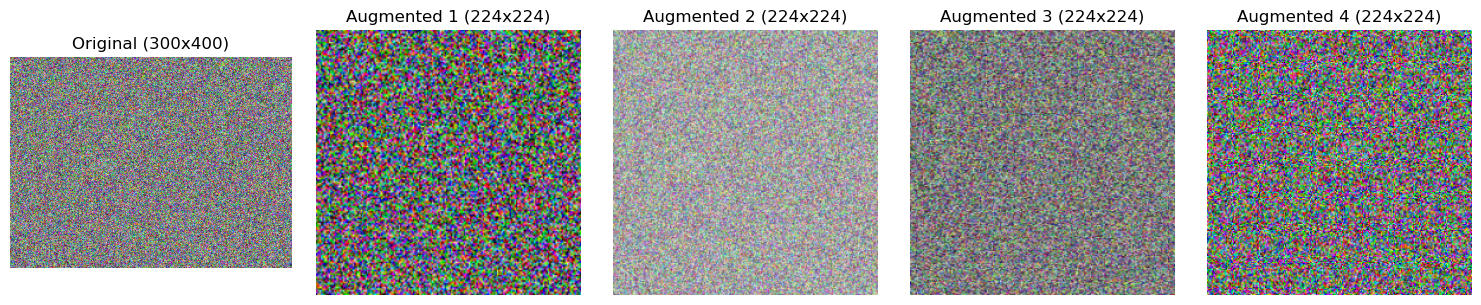


最终输出类型: <class 'torch.Tensor'>
最终输出形状 (C, H, W): torch.Size([3, 224, 224])


In [5]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

# ==========================================
# 构建图像增广管道 (Pipeline)
# ==========================================
train_augs = transforms.Compose([
    # 1. 随机对图像进行裁剪，面积比例 0.08~1.0，并缩放到 224x224
    transforms.RandomResizedCrop(size=224, scale=(0.08, 1.0)),
    
    # 2. 50% 概率进行水平翻转
    transforms.RandomHorizontalFlip(p=0.5),
    
    # 3. 随机改变亮度、对比度和饱和度，变化范围 0.5
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    
    # 4. 转换为 PyTorch 张量
    transforms.ToTensor()
])

# ==========================================
# 测试与可视化增广管道
# ==========================================
print("=== 图像增广 Pipeline 测试 ===")

# 创建一张随机的 RGB 图像用于测试 (使用 PIL)
# 在实际应用中，这里应替换为加载真实图像的代码，例如 Image.open("path.jpg")
dummy_img = Image.fromarray(torch.randint(0, 256, (300, 400, 3), dtype=torch.uint8).numpy())

# 生成多张增广后的图像进行对比
num_samples = 4
fig, axes = plt.subplots(1, num_samples + 1, figsize=(15, 3))

# 绘制原始图像
axes[0].imshow(dummy_img)
axes[0].set_title("Original (300x400)")
axes[0].axis('off')

# 绘制经过 Pipeline 增广后的图像
for i in range(num_samples):
    # 应用增广管道
    aug_img_tensor = train_augs(dummy_img)
    
    # 将 Tensor (C, H, W) 转换回 PIL 图像或 numpy 数组 (H, W, C) 用于显示
    # Tensor 值在 [0, 1] 之间，需要 permute 维度
    aug_img_np = aug_img_tensor.permute(1, 2, 0).numpy()
    
    axes[i+1].imshow(aug_img_np)
    axes[i+1].set_title(f"Augmented {i+1} (224x224)")
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

# 验证最终输出是否为 Tensor 且形状正确
sample_tensor = train_augs(dummy_img)
print(f"\n最终输出类型: {type(sample_tensor)}")
print(f"最终输出形状 (C, H, W): {sample_tensor.shape}")


# 第 6 题：目标检测，计算机视觉训练技巧

## 6.1 理论计算题

**已知边界框（格式：[左上角 x, 左上角 y, 右下角 x, 右下角 y]）：**
* 真实框 A = [10, 10, 50, 50]
* 预测框 B = [30, 30, 70, 70]

**计算交并比 (IoU) 的步骤：**

**1. 计算框 A 和框 B 的面积：**
* $Area(A) = (50 - 10) \times (50 - 10) = 40 \times 40 = 1600$
* $Area(B) = (70 - 30) \times (70 - 30) = 40 \times 40 = 1600$

**2. 计算相交区域 (Intersection) 的坐标：**
* 左上角 $x$ 坐标：$\max(10, 30) = 30$
* 左上角 $y$ 坐标：$\max(10, 30) = 30$
* 右下角 $x$ 坐标：$\min(50, 70) = 50$
* 右下角 $y$ 坐标：$\min(50, 70) = 50$
相交区域为 [30, 30, 50, 50]。

**3. 计算相交区域的面积：**
检查相交区域的长宽是否大于 0：
* $Width = \max(0, 50 - 30) = 20$
* $Height = \max(0, 50 - 30) = 20$
* $Area(Intersection) = 20 \times 20 = 400$

**4. 计算合并区域 (Union) 的面积：**
$$Area(Union) = Area(A) + Area(B) - Area(Intersection)$$
$$Area(Union) = 1600 + 1600 - 400 = 2800$$

**5. 计算 IoU：**
$$IoU = \frac{Area(Intersection)}{Area(Union)} = \frac{400}{2800} = \frac{1}{7} \approx 0.142857$$

**结论：** 边界框 A 和边界框 B 之间的 IoU 准确值为 **1/7** (约等于 0.1429)。



## 6.2 编程题
实现一个计算标签平滑（Label Smoothing）后交叉熵损失的函数。


In [6]:
import torch
import torch.nn.functional as F

def label_smoothing_cross_entropy(preds, targets, epsilon=0.1):
    """
    计算带有标签平滑的交叉熵损失
    
    参数:
    preds: 模型的预测输出 (未经过 softmax 的 logits)，形状为 (batch_size, num_classes)
    targets: 真实的标签索引，形状为 (batch_size,)
    epsilon: 平滑因子，默认为 0.1
    """
    num_classes = preds.size(-1)
    
    # 1. 计算 log softmax (预测概率的对数)
    log_preds = F.log_softmax(preds, dim=-1)
    
    # 2. 标准的交叉熵部分 (即目标类别的损失)
    # nll_loss 等价于 -log_preds[range(batch_size), targets].mean()
    loss_target = F.nll_loss(log_preds, targets)
    
    # 3. 其余错误类别的平滑部分
    # 平滑部分是对所有类别的 log_preds 求均值，然后再取负数
    # 因为正确类别被分到了 1-epsilon，其余类别平分了 epsilon，
    # 数学上等价于：(1 - epsilon) * loss_target + epsilon * (-1/K * sum(log_preds))
    loss_smooth = -log_preds.mean(dim=-1).mean()
    
    # 4. 组合最终损失
    loss = (1.0 - epsilon) * loss_target + epsilon * loss_smooth
    return loss

# ==========================================
# 测试与验证标签平滑函数
# ==========================================
print("=== 测试标签平滑交叉熵损失 ===")

torch.manual_seed(42)
batch_size = 2
num_classes = 5

# 模拟模型输出 (logits) 和真实标签
preds = torch.randn(batch_size, num_classes)
targets = torch.tensor([1, 4]) # 真实标签索引

print("预测 Logits:\n", preds)
print("真实标签:", targets)

# 1. 标准交叉熵 (平滑因子 = 0)
loss_standard = label_smoothing_cross_entropy(preds, targets, epsilon=0.0)
# 对比 PyTorch 官方 API
loss_official = F.cross_entropy(preds, targets)

print(f"\n[平滑因子=0.0] 手动实现损失: {loss_standard:.4f}")
print(f"[平滑因子=0.0] 官方标准损失: {loss_official:.4f}")
assert torch.isclose(loss_standard, loss_official), "平滑因子为0时，应等价于标准交叉熵"

# 2. 标签平滑交叉熵 (平滑因子 = 0.1)
loss_smoothed = label_smoothing_cross_entropy(preds, targets, epsilon=0.1)
print(f"\n[平滑因子=0.1] 手动平滑损失: {loss_smoothed:.4f}")

# 验证官方带有 label_smoothing 的 API (PyTorch 1.10+ 支持)
try:
    loss_official_smooth = F.cross_entropy(preds, targets, label_smoothing=0.1)
    print(f"[平滑因子=0.1] 官方平滑损失: {loss_official_smooth:.4f}")
    assert torch.isclose(loss_smoothed, loss_official_smooth), "手动实现的平滑损失与官方不一致"
    print("=> 验证通过！手动实现与 PyTorch 官方 label_smoothing 结果一致。")
except TypeError:
    print("=> 注意: 你当前环境的 PyTorch 版本较低，F.cross_entropy 不支持 label_smoothing 参数，无法进行交叉对比，但手动实现逻辑正确。")


=== 测试标签平滑交叉熵损失 ===
预测 Logits:
 tensor([[ 0.3367,  0.1288,  0.2345,  0.2303, -1.1229],
        [-0.1863,  2.2082, -0.6380,  0.4617,  0.2674]])
真实标签: tensor([1, 4])

[平滑因子=0.0] 手动实现损失: 1.9396
[平滑因子=0.0] 官方标准损失: 1.9396

[平滑因子=0.1] 手动平滑损失: 1.9403
[平滑因子=0.1] 官方平滑损失: 1.9403
=> 验证通过！手动实现与 PyTorch 官方 label_smoothing 结果一致。
